## Helper functions

In [1]:
import pandas as pd
from pathlib import Path
file_name = 'Front_EE-1_1_3000x_rings_coords.csv'
path_to_main_folder = Path('/Users/rishabhkumar/spiral-chirals')
# csv_file = Path('/Users/rishabhkumar/spiral-chirals/vf_exports/Front_EE-1_1_3000x_rings_coords.csv')
csv_file = path_to_main_folder / 'vf_exports' / file_name
with open(csv_file, 'r') as f:
    df = pd.read_csv(f)

print(df.head())
# remove the last row 
df = df.iloc[:-1]


  Ring     Coordinate  Angle (α′)        Pattern
0    1   (7.00, 0.00)      -26.09      Clockwise
1    1  (0.00, -7.00)       58.86  Anticlockwise
2    1  (-7.00, 0.00)      -31.99      Clockwise
3    1   (0.00, 7.00)       73.30  Anticlockwise
4    2  (43.00, 0.00)      -11.86      Clockwise


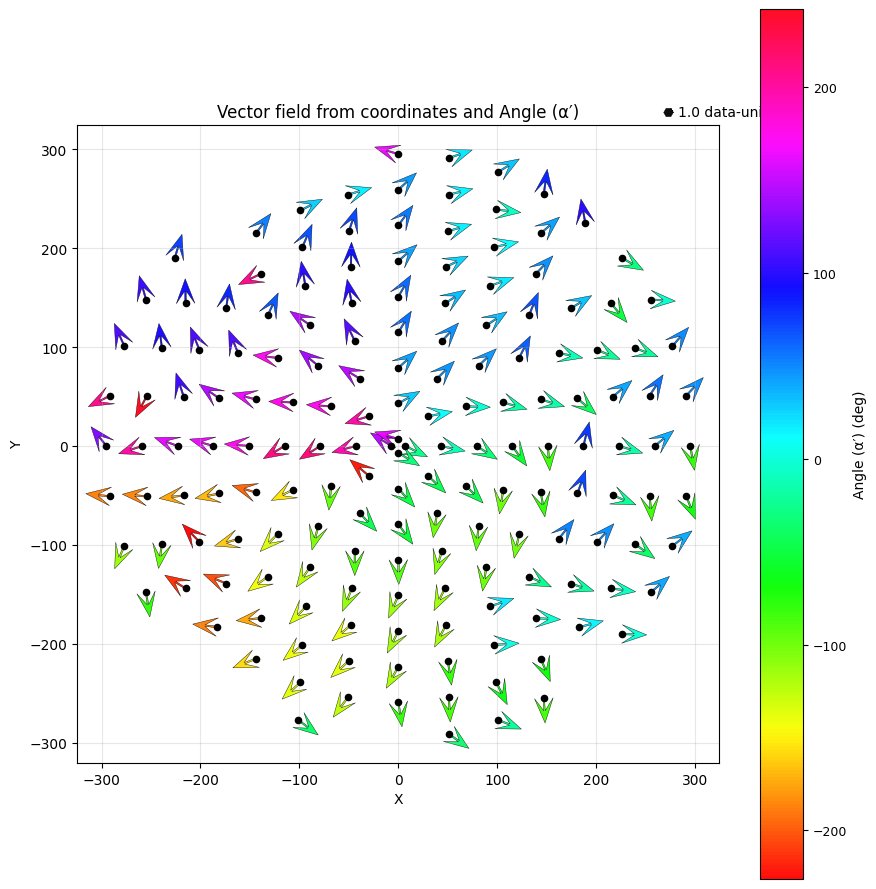

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# helper functions 
import ast

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]
# Extract angles and filter valid data
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 

# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
r = np.sqrt(np.array(X)**2 + np.array(Y)**2)
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)
phi_rad = np.deg2rad(phi)
U_plot = np.cos(phi_rad)
V_plot = np.sin(phi_rad)
# Compute a reasonable scale factor for the quiver key
scale_factor = np.round(np.percentile(np.sqrt(U_plot**2 + V_plot**2), 75), 1)
if scale_factor == 0:
    scale_factor = 1.0
# Create the plot
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U_plot_scaled = magnitude_scale * U_plot
V_plot_scaled = magnitude_scale * V_plot
q = plt.quiver(
    X, Y, U_plot_scaled, V_plot_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Vector field from coordinates and Angle (α′)')
cbar = plt.colorbar(q, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vector_field_plot.svg', dpi=300)
plt.show()

In [ ]:
## Likelihood calculation using line field approach
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def line_field_pdf(psi, phi_0, m, sigma):
    """
    Calculates the probability density for the line field model.
    
    Args:
        psi (float or np.array): The data points (angles in radians).
        phi_0 (float): The orientation parameter to estimate.
        m (float): Magnitude/strength parameter.
        sigma (float): Standard deviation parameter.
        
    Returns:
        np.array: The probability density values.
    """
    # Calculate the angular difference
    delta = psi - phi_0
    
    # Pre-calculate common terms for efficiency
    cos_d = np.cos(delta)
    sin_d = np.sin(delta)
    m_sigma_ratio = m / sigma
    
    # Term 1: The isotropic baseline
    # Note: Using 1/pi as per your handwritten note
    term1 = (1.0 / np.pi) * np.exp(-0.5 * (m_sigma_ratio**2))
    
    # Term 2: The directional component
    # The exponential part: exp(-m^2 * sin^2 / 2sigma^2)
    exp_part = np.exp(-0.5 * (m_sigma_ratio * sin_d)**2)
    
    # The Phi part: 2 * Phi(...) - 1
    # Note: norm.cdf is the standard normal CDF (Phi)
    phi_arg = m_sigma_ratio * cos_d
    bracket_term = 2 * norm.cdf(phi_arg) - 1
    
    # Combine Term 2
    # coefficient: m * cos(delta) * (1 / (sqrt(2pi) * sigma))
    coeff = m * cos_d * (1.0 / (np.sqrt(2 * np.pi) * sigma))
    term2 = coeff * exp_part * bracket_term
    
    return term1 + term2

def neg_log_likelihood(params, psi_data, m, sigma):
    """
    The objective function to minimize.
    """
    phi_0 = params[0]
    
    # Calculate PDF values
    pdf_vals = line_field_pdf(psi_data, phi_0, m, sigma)
    
    # Safety check: Prevent log(0) or negative values due to float precision
    epsilon = 1e-15
    pdf_vals = np.maximum(pdf_vals, epsilon)
    
    # Return negative sum of logs
    return -np.sum(np.log(pdf_vals))

# --- Example Usage ---

# 1. Generate Dummy Data (Ground Truth: phi_0 = 1.0 radian)

# 3. Output Results
if result.success:
    estimated_phi = result.x[0]
    print(f"Optimization Successful!")
    print(f"True Phi_0 (approx): {true_phi}")
    print(f"Estimated Phi_0:     {estimated_phi:.4f}")
    print(f"Negative Log Likelihood: {result.fun:.4f}")
else:
    print("Optimization failed:", result.message)

Optimization Successful!
True Phi_0 (approx): 1.0
Estimated Phi_0:     0.9836
Negative Log Likelihood: 90.5293


--- Test Case: A=1.0, b=0.5, p=1.0, r=2.0 ---
Theoretical phi_0: -0.244979 rad (-14.04 deg)
Numerical Max psi: -0.244979 rad (-14.04 deg)
Peak PDF Density:  1.5958
✅ SUCCESS: Numerical max matches theoretical vector field angle.




<>:98: SyntaxWarning: invalid escape sequence '\s'
<>:99: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\s'
<>:99: SyntaxWarning: invalid escape sequence '\p'
/var/folders/5r/6f18fbm17wl8t8q50sb5hrvc0000gn/T/ipykernel_69772/1172141694.py:98: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(psi_vals, pdf_vals, label=f'PDF ($m={m}, \sigma={sigma}$)', linewidth=2)
/var/folders/5r/6f18fbm17wl8t8q50sb5hrvc0000gn/T/ipykernel_69772/1172141694.py:99: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(phi0, color='r', linestyle='--', label=f'Theoretical $\phi_0$ ({phi0:.2f})')


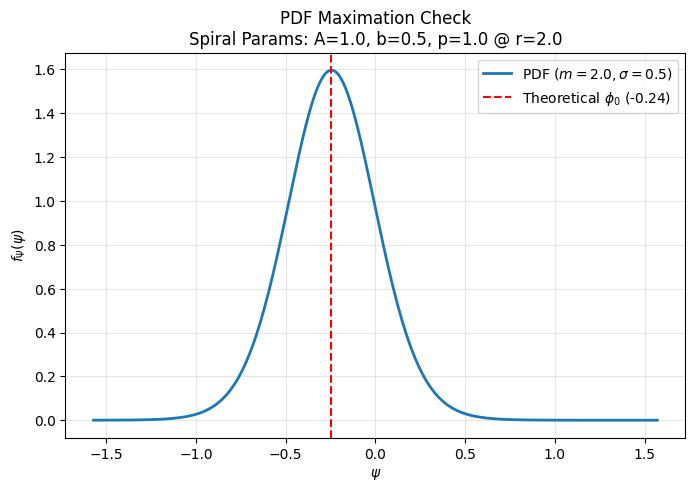

In [5]:
## Test the maximization of the likelihood function
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize_scalar

def projected_normal_pdf(psi, m, sigma, phi0):
    """
    Computes the PDF value f_Psi(psi) based on the user's formula.
    """
    # Pre-compute common terms
    diff = psi - phi0
    cos_d = np.cos(diff)
    sin_d = np.sin(diff)
    
    # Term 1: The isotropic gaussian background
    term1 = (1.0 / np.pi) * np.exp(-m**2 / (2 * sigma**2))
    
    # Term 2: The directional component
    # Part A: Coefficient
    coeff = (m * cos_d) / (np.sqrt(2 * np.pi) * sigma)
    
    # Part B: Exponential
    exp_part = np.exp(-(m**2 * sin_d**2) / (2 * sigma**2))
    
    # Part C: CDF term (2*Phi(...) - 1)
    # Note: 2*Phi(x) - 1 is equivalent to erf(x/sqrt(2))
    cdf_arg = (m * cos_d) / sigma
    cdf_part = 2 * norm.cdf(cdf_arg) - 1
    
    term2 = coeff * exp_part * cdf_part
    
    return term1 + term2

def get_theoretical_phi0(A, b, p, r):
    """
    Calculates the theoretical angle phi_0 from the spiral vector field parameters.
    Formula: tan(phi_0) = F_phi / F_r = -b / (A * r^p)
    """
    # Denominator (Radial component coefficient)
    denom = A * (r**p)
    
    # We use arctan to stay strictly within (-pi/2, pi/2) as requested
    # by the domain constraint psi \in (-pi/2, pi/2].
    phi0 = np.arctan(-b / denom)
    return phi0

def run_test_case(A, b, p, r, m, sigma):
    print(f"--- Test Case: A={A}, b={b}, p={p}, r={r} ---")
    
    # 1. Calculate Theoretical phi_0
    phi0_theory = get_theoretical_phi0(A, b, p, r)
    print(f"Theoretical phi_0: {phi0_theory:.6f} rad ({np.degrees(phi0_theory):.2f} deg)")

    # 2. Find Numerical Maximum of the PDF
    # We minimize the negative PDF to find the maximum
    res = minimize_scalar(
        lambda psi: -projected_normal_pdf(psi, m, sigma, phi0_theory),
        bounds=(-np.pi/2 + 1e-6, np.pi/2), # Slightly offset from -pi/2 to avoid edge cases
        method='bounded'
    )
    
    psi_max_numeric = res.x
    max_val = -res.fun
    
    print(f"Numerical Max psi: {psi_max_numeric:.6f} rad ({np.degrees(psi_max_numeric):.2f} deg)")
    print(f"Peak PDF Density:  {max_val:.4f}")
    
    # 3. Validation
    error = abs(psi_max_numeric - phi0_theory)
    if error < 1e-5:
        print("✅ SUCCESS: Numerical max matches theoretical vector field angle.")
    else:
        print(f"❌ MISMATCH: Error is {error:.6f}")
    print("\n")
    return phi0_theory

# --- Execution ---

# Parameters for the Spiral Vector Field
A = 1.0     # Radial strength
b = 0.5     # Rotation strength
p = 1.0     # Power law for g_p(r)
r = 2.0     # Current radius

# Parameters for the Distribution (Concentration)
m = 2.0     # Mean magnitude
sigma = 0.5 # Standard deviation

# Run validation
phi0 = run_test_case(A, b, p, r, m, sigma)

# --- Plotting the result ---
psi_vals = np.linspace(-np.pi/2, np.pi/2, 500)
pdf_vals = projected_normal_pdf(psi_vals, m, sigma, phi0)

plt.figure(figsize=(8, 5))
plt.plot(psi_vals, pdf_vals, label=f'PDF ($m={m}, \sigma={sigma}$)', linewidth=2)
plt.axvline(phi0, color='r', linestyle='--', label=f'Theoretical $\phi_0$ ({phi0:.2f})')
plt.title(f'PDF Maximation Check\nSpiral Params: A={A}, b={b}, p={p} @ r={r}')
plt.xlabel(r'$\psi$')
plt.ylabel(r'$f_\Psi(\psi)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running 3D Grid Search...
Est. Params: A=3.50, b=2.00, p=0.60


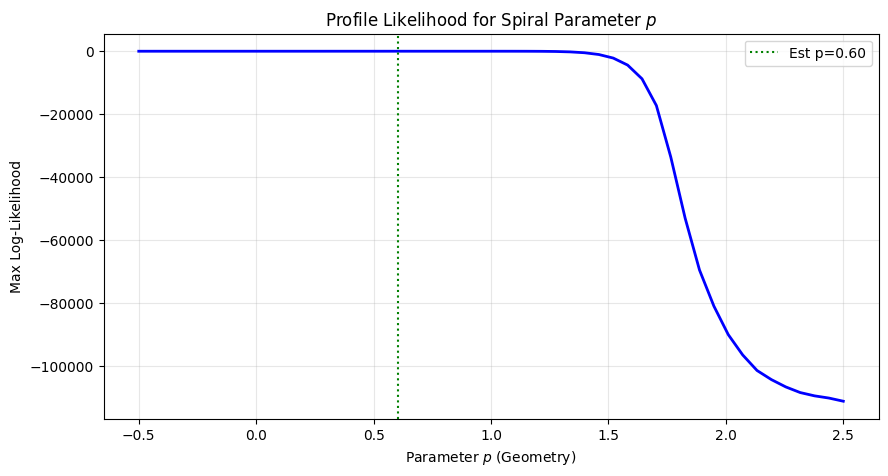

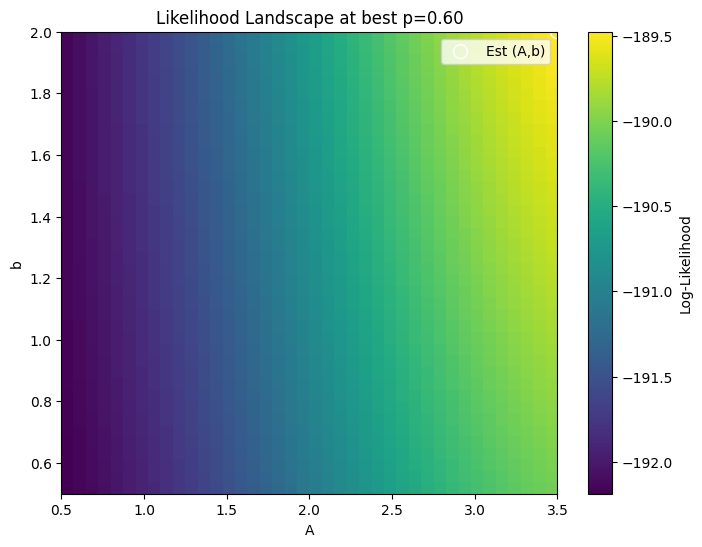

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def exact_projected_normal_pdf_3d(psi, phi0, m, sigma):
    """
    Computes PDF for 3D parameter grid inputs.
    """
    # Term 1: Background
    term1 = (1.0 / np.pi) * np.exp(-m**2 / (2 * sigma**2))
    
    diff = psi - phi0
    cos_d = np.cos(diff)
    sin_d = np.sin(diff)
    
    # Term 2: Directional
    coeff = (m * cos_d) / (np.sqrt(2 * np.pi) * sigma)
    exp_part = np.exp(-(m**2 * sin_d**2) / (2 * sigma**2))
    cdf_part = 2 * norm.cdf((m * cos_d) / sigma) - 1
    
    term2 = coeff * exp_part * cdf_part
    return np.maximum(term1 + term2, 1e-300)

def grid_search_3d(r_data, psi_data, param_ranges, sigma=1.0):
    """
    Performs MLE over (A, b, p).
    param_ranges: tuple (A_vals, b_vals, p_vals)
    """
    A_vals, b_vals, p_vals = param_ranges
    
    # 1. Create 4D Meshgrid
    # Dimensions: (Na, Nb, Np, N_data)
    # We use indexing='ij' so the dimensions order is A, b, p
    A_grid, b_grid, p_grid = np.meshgrid(A_vals, b_vals, p_vals, indexing='ij')
    
    # Expand to 4D for broadcasting against data
    A_4d = A_grid[..., np.newaxis]
    b_4d = b_grid[..., np.newaxis]
    p_4d = p_grid[..., np.newaxis]
    
    # Data shapes: (1, 1, 1, N_data)
    r_4d = r_data[np.newaxis, np.newaxis, np.newaxis, :]
    psi_4d = psi_data[np.newaxis, np.newaxis, np.newaxis, :]
    
    # 2. Vector Field Calculation (Universal Formula)
    # Fr = A * r^(p-1). This works for p=0 (1/r) and p!=0.
    Fr = A_4d * (r_4d ** (p_4d - 1.0))
    Fphi = -b_4d / r_4d
    
    # Magnitude and Phase
    m_4d = np.sqrt(Fr**2 + Fphi**2)
    phi0_4d = np.arctan(Fphi / (Fr + 1e-12))
    
    # 3. Compute PDF & Likelihood
    pdf_vals = exact_projected_normal_pdf_3d(psi_4d, phi0_4d, m_4d, sigma)
    
    # Sum logs over data dimension (axis 3)
    # Result shape: (Na, Nb, Np)
    log_likelihood_vol = np.sum(np.log(pdf_vals), axis=3)
    
    # 4. Find Global Maximum
    max_idx = np.unravel_index(np.argmax(log_likelihood_vol), log_likelihood_vol.shape)
    best_params = {
        'A': A_vals[max_idx[0]],
        'b': b_vals[max_idx[1]],
        'p': p_vals[max_idx[2]],
        'LL': log_likelihood_vol[max_idx]
    }
    
    return log_likelihood_vol, best_params

# --- Simulation and Test ---

# 1. Generate Data with a specific geometry (e.g., p=0.5)
# np.random.seed(101)
# true_p = 1.05   # Between Log and Archimedean
# true_A = 2.0
# true_b = 1.0
# sigma_sim = 0.6
# N = 600

# r_obs = np.linspace(1, 10, N)
# # True Vector Field
# Fr_true = true_A * (r_obs**(true_p - 1))
# Fphi_true = -true_b / r_obs
# phi_true = np.arctan(Fphi_true / Fr_true)
# psi_obs = phi_true + np.random.normal(0, 0.1, N) # Small noise
# psi_obs = np.clip(psi_obs, -np.pi/2+0.01, np.pi/2-0.01)

# Load data
# psi_obs = phi mod \pi
# r_obs = r_obs

psi_obs = phi_rad % np.pi
r_obs = np.sqrt(np.array(X)**2 + np.array(Y)**2)  # Recalculate from X, Y arrays

# 2. Define Search Ranges
# Note: 3D grids grow fast. Keep resolution manageable.
A_vals = np.linspace(0.5, 3.5, 40)
b_vals = np.linspace(0.5, 2.0, 40)
p_vals = np.linspace(-0.5, 2.5, 50) # Searching across different geometries

# 3. Run Search
print("Running 3D Grid Search...")
LL_vol, res = grid_search_3d(r_obs, psi_obs, (A_vals, b_vals, p_vals), sigma=1.0)

# print(f"True Params: A={true_A}, b={true_b}, p={true_p}")
print(f"Est. Params: A={res['A']:.2f}, b={res['b']:.2f}, p={res['p']:.2f}")

# --- Visualization: Profile Likelihood of p ---
# We take the max over A and b for each p.
# This answers: "For a fixed p, what is the best possible fit?"
profile_likelihood_p = np.max(LL_vol, axis=(0, 1))

plt.figure(figsize=(10, 5))
plt.plot(p_vals, profile_likelihood_p, 'b-', linewidth=2)
# plt.axvline(true_p, color='r', linestyle='--', label=f'True p={true_p}')
plt.axvline(res['p'], color='g', linestyle=':', label=f'Est p={res["p"]:.2f}')

plt.title('Profile Likelihood for Spiral Parameter $p$')
plt.xlabel('Parameter $p$ (Geometry)')
plt.ylabel('Max Log-Likelihood')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Visualization 2: Slice at best p ---
# We plot the A-b landscape at the optimal p index
best_p_idx = np.where(p_vals == res['p'])[0][0]
LL_slice = LL_vol[:, :, best_p_idx]

plt.figure(figsize=(8, 6))
plt.imshow(
    LL_slice.T, 
    extent=[A_vals.min(), A_vals.max(), b_vals.min(), b_vals.max()],
    origin='lower', aspect='auto', cmap='viridis'
)
plt.colorbar(label='Log-Likelihood')
# plt.scatter([true_A], [true_b], color='red', marker='x', label='True (A,b)')
plt.scatter([res['A']], [res['b']], facecolors='none', edgecolors='white', s=100, label='Est (A,b)')
plt.title(f'Likelihood Landscape at best p={res["p"]:.2f}')
plt.xlabel('A')
plt.ylabel('b')
plt.legend()
plt.show()

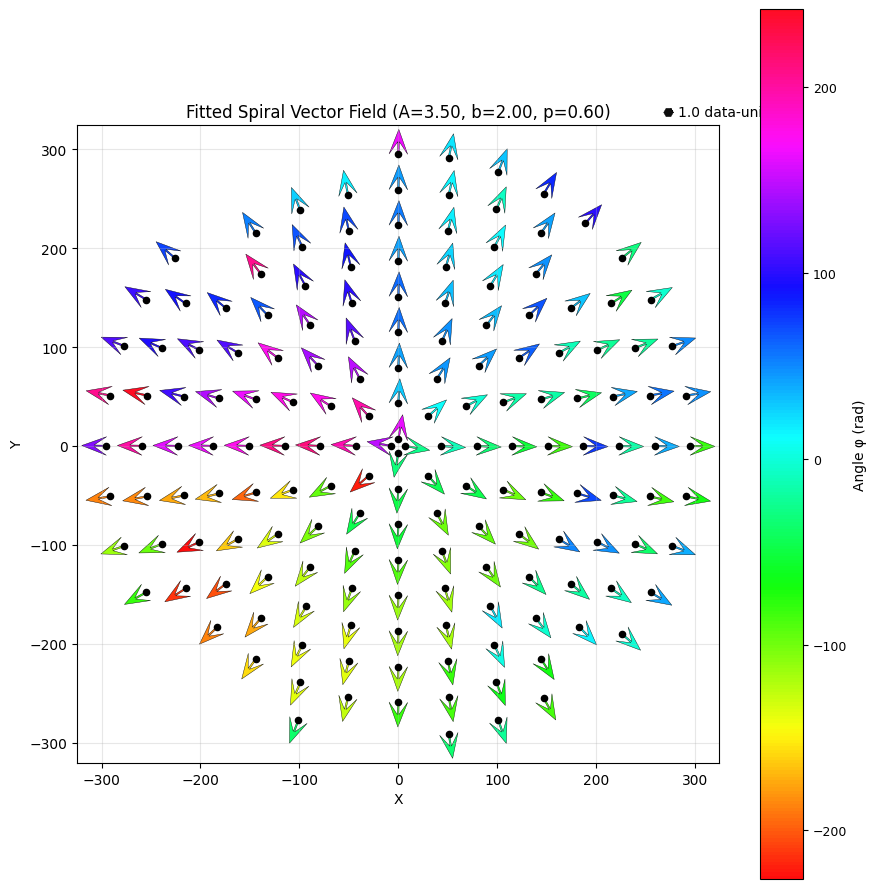

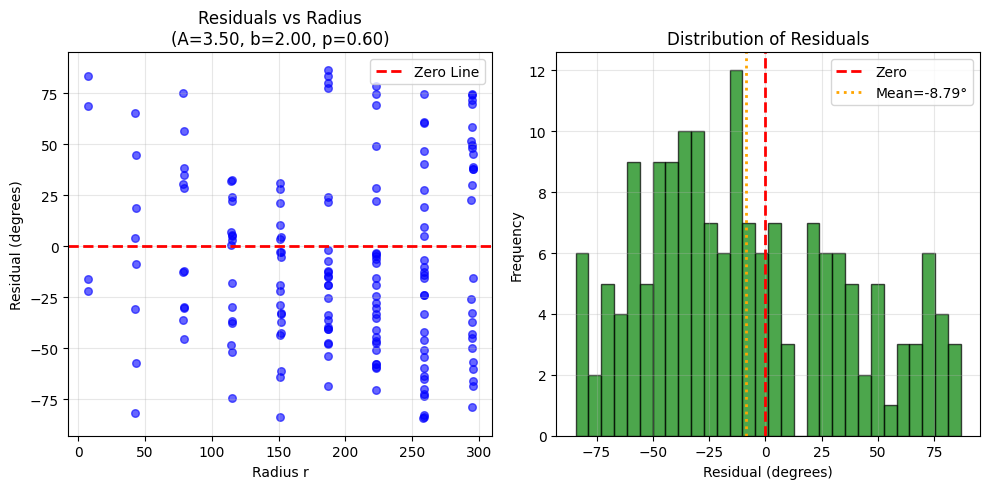


--- Residual Statistics ---
Mean Residual: -8.7856°
Std Residual:  44.6612°
RMSE:          45.5171°
Max |Residual|: 86.6925°


In [15]:
# --- Visualization: Fitted Vector Field ---
# Reconstruct the vector field using the estimated parameters
A_est = res['A']
b_est = res['b']
p_est = res['p']

# Calculate the fitted vector field components
Fr_fit = A_est * (r_obs ** (p_est - 1.0))
Fphi_fit = -b_est / r_obs

# Convert to Cartesian components for plotting
# The fitted field angle in the local polar frame
phi_fit = np.arctan2(Fphi_fit, Fr_fit)

# Convert to global frame (add theta)
phi_global_fit = phi_fit + theta

# Compute Cartesian components
U_fit = np.cos(phi_global_fit)
V_fit = np.sin(phi_global_fit)

# Scale for visualization
magnitude_scale = 25.0
U_fit_scaled = magnitude_scale * U_fit
V_fit_scaled = magnitude_scale * V_fit

# Create the plot
plt.figure(figsize=(9, 9))
q_fit = plt.quiver(
    X, Y, U_fit_scaled, V_fit_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Fitted Spiral Vector Field (A={A_est:.2f}, b={b_est:.2f}, p={p_est:.2f})')
cbar = plt.colorbar(q_fit, label='Angle φ (rad)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q_fit, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spiral_vector_field_fit_mle.svg', dpi=300)
plt.show()

# --- Plot Residuals ---
# Calculate fitted angles in local polar frame
phi_fit_local = np.arctan(Fphi_fit / Fr_fit)

# Observed angles in local polar frame (psi_obs is already computed)
# Convert from modulo pi back to the correct range for residuals
angles_local_obs = psi_obs  # This is phi_rad % pi from earlier

# For proper residuals, we need the unwrapped version
# Use the original phi_rad instead
angles_local_obs_unwrapped = phi_rad - theta  # Remove global rotation to get local angle

# Calculate residuals (in radians)
residuals_fit = angles_local_obs_unwrapped - phi_fit_local

# Convert to degrees for plotting
residuals_fit_deg = np.degrees(residuals_fit)

# Residual scatter plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(r_obs, residuals_fit_deg, color='blue', alpha=0.6, s=30)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Line')
plt.xlabel('Radius r')
plt.ylabel('Residual (degrees)')
plt.title(f'Residuals vs Radius\n(A={A_est:.2f}, b={b_est:.2f}, p={p_est:.2f})')
plt.legend()
plt.grid(alpha=0.3)

# Residual histogram
plt.subplot(1, 2, 2)
plt.hist(residuals_fit_deg, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
plt.axvline(np.mean(residuals_fit_deg), color='orange', linestyle=':', 
            linewidth=2, label=f'Mean={np.mean(residuals_fit_deg):.2f}°')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('spiral_fit_residuals_mle.svg', dpi=300)
plt.show()

# Print residual statistics
print(f"\n--- Residual Statistics ---")
print(f"Mean Residual: {np.mean(residuals_fit_deg):.4f}°")
print(f"Std Residual:  {np.std(residuals_fit_deg):.4f}°")
print(f"RMSE:          {np.sqrt(np.mean(residuals_fit_deg**2)):.4f}°")
print(f"Max |Residual|: {np.max(np.abs(residuals_fit_deg)):.4f}°")

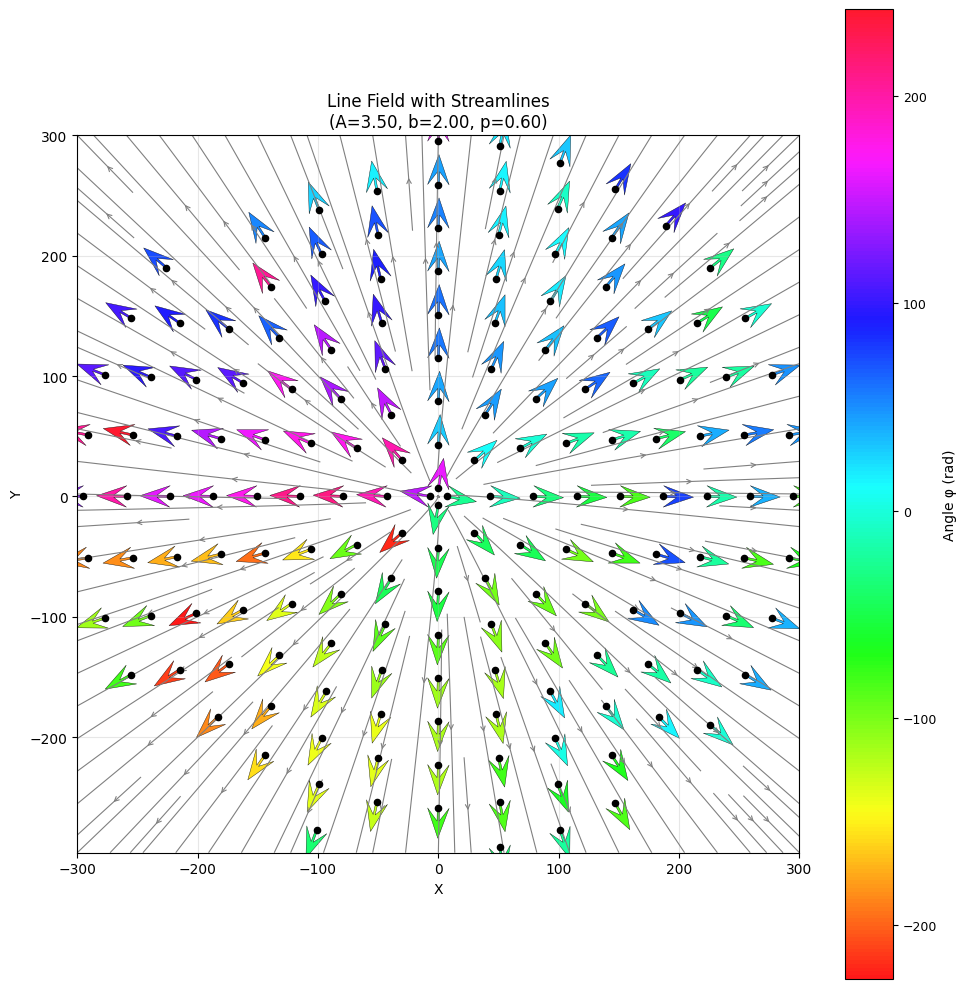

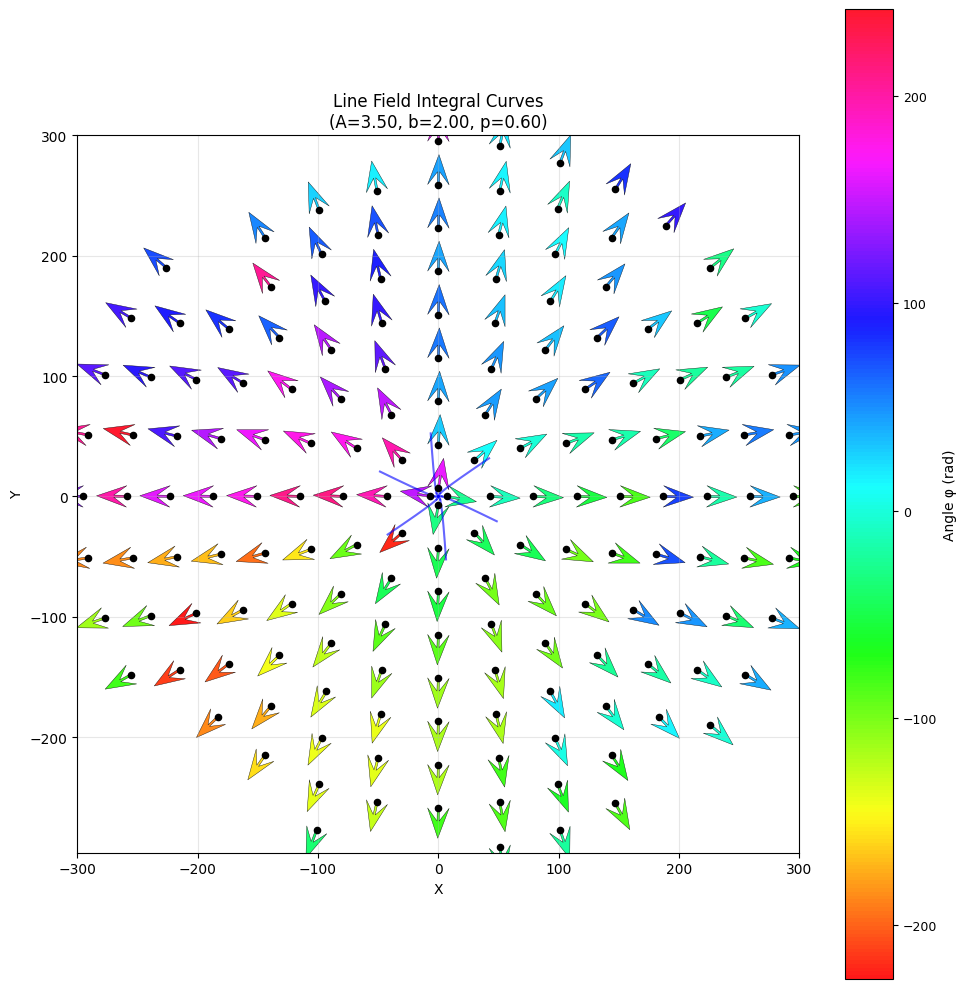

In [18]:
# --- Visualization: Line Field with Streamlines ---
# Plot the fitted vector field with integral curves (streamlines)

plt.figure(figsize=(10, 10))

# Create a dense grid for streamline computation
x_min, x_max = min(X) - 5, max(X) + 5
y_min, y_max = min(Y) - 5, max(Y) + 5
x_grid = np.linspace(x_min, x_max, 200)
y_grid = np.linspace(y_min, y_max, 200)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Convert grid to polar coordinates
R_grid = np.sqrt(X_grid**2 + Y_grid**2)
Theta_grid = np.arctan2(Y_grid, X_grid)

# Calculate vector field on the grid using fitted parameters
Fr_grid = A_est * (R_grid ** (p_est - 1.0))
Fphi_grid = -b_est / R_grid

# Local field angle
phi_local_grid = np.arctan2(Fphi_grid, Fr_grid)

# Convert to global frame
phi_global_grid = phi_local_grid + Theta_grid

# Cartesian components on grid
U_grid = np.cos(phi_global_grid)
V_grid = np.sin(phi_global_grid)

# Plot streamlines (integral curves of the vector field)
# These represent the line field lines
plt.streamplot(
    X_grid, Y_grid, U_grid, V_grid,
    color='gray', 
    density=1.5,  # Adjust for more/fewer lines
    linewidth=0.8,
    arrowsize=0.8,
    arrowstyle='->',
    integration_direction='both'
)

# Overlay the quiver plot with observed data
q_fit = plt.quiver(
    X, Y, U_fit_scaled, V_fit_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.012,
    headwidth=10,
    headlength=14,
    headaxislength=8,
    alpha=0.9, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Line Field with Streamlines\n(A={A_est:.2f}, b={b_est:.2f}, p={p_est:.2f})')
cbar = plt.colorbar(q_fit, label='Angle φ (rad)')
cbar.ax.tick_params(labelsize=9)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('line_field_streamlines_mle.svg', dpi=300)
plt.show()

# --- Alternative: Plot individual line field lines starting from specific points ---
plt.figure(figsize=(10, 10))

# Define starting points for line field lines (e.g., on a circle)
n_lines = 6
angles_start = np.linspace(0, 2*np.pi, n_lines, endpoint=False)
r_start = 3.0  # Starting radius

# Integrate line field lines using scipy.integrate
from scipy.integrate import solve_ivp

def vector_field_ode(t, state):
    """ODE for line field: dx/dt = U(x,y), dy/dt = V(x,y)"""
    x, y = state
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    if r < 0.1:  # Avoid singularity at origin
        return [0, 0]
    
    # Vector field components
    Fr = A_est * (r ** (p_est - 1.0))
    Fphi = -b_est / r
    phi_local = np.arctan2(Fphi, Fr)
    phi_global = phi_local + theta
    
    return [np.cos(phi_global), np.sin(phi_global)]

# Plot line field lines
for angle in angles_start:
    x0 = r_start * np.cos(angle)
    y0 = r_start * np.sin(angle)
    
    # Integrate forward
    sol_forward = solve_ivp(
        vector_field_ode, 
        [0, 50],  # Time span
        [x0, y0],
        max_step=0.1,
        dense_output=True
    )
    
    # Integrate backward
    sol_backward = solve_ivp(
        vector_field_ode,
        [0, -50],  # Negative time
        [x0, y0],
        max_step=0.1,
        dense_output=True
    )
    
    # Plot both directions
    plt.plot(sol_forward.y[0], sol_forward.y[1], 'b-', linewidth=1.5, alpha=0.6)
    plt.plot(sol_backward.y[0], sol_backward.y[1], 'b-', linewidth=1.5, alpha=0.6)

# Overlay observed data
q_fit = plt.quiver(
    X, Y, U_fit_scaled, V_fit_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.012,
    headwidth=10,
    headlength=14,
    headaxislength=8,
    alpha=0.9, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Line Field Integral Curves\n(A={A_est:.2f}, b={b_est:.2f}, p={p_est:.2f})')
cbar = plt.colorbar(q_fit, label='Angle φ (rad)')
cbar.ax.tick_params(labelsize=9)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('line_field_curves_mle.svg', dpi=300)
plt.show()